In [1]:
# 05_clv_model_building

In [8]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
rfm = pd.read_csv('../data/rfm_data.csv')
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment
0,326,1,77183.60,1,1,5,115,Lost
1,2,7,4310.00,5,5,5,555,Champions
2,75,4,1437.24,2,4,4,244,Loyal Customers
3,19,1,1457.55,4,1,4,414,Potential Loyalists
4,310,1,294.40,1,1,2,112,Lost


In [3]:
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,AOV
0,326,1,77183.60,1,1,5,115,Lost,77183.600000
1,2,7,4310.00,5,5,5,555,Champions,615.714286
2,75,4,1437.24,2,4,4,244,Loyal Customers,359.310000
3,19,1,1457.55,4,1,4,414,Potential Loyalists,1457.550000
4,310,1,294.40,1,1,2,112,Lost,294.400000


In [4]:
rfm['Purchase_Frequency'] = rfm['Frequency']

In [5]:
rfm['Lifespan_Score'] = 365 - rfm['Recency']

In [6]:
rfm['CLV'] = rfm['AOV'] * rfm['Purchase_Frequency'] * (rfm['Lifespan_Score'] / 365)
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_Score,Segment,AOV,Purchase_Frequency,Lifespan_Score,CLV
0,326,1,77183.60,1,1,5,115,Lost,77183.600000,1,39,8247.014795
1,2,7,4310.00,5,5,5,555,Champions,615.714286,7,363,4286.383562
2,75,4,1437.24,2,4,4,244,Loyal Customers,359.310000,4,290,1141.916712
3,19,1,1457.55,4,1,4,414,Potential Loyalists,1457.550000,1,346,1381.677534
4,310,1,294.40,1,1,2,112,Lost,294.400000,1,55,44.361644


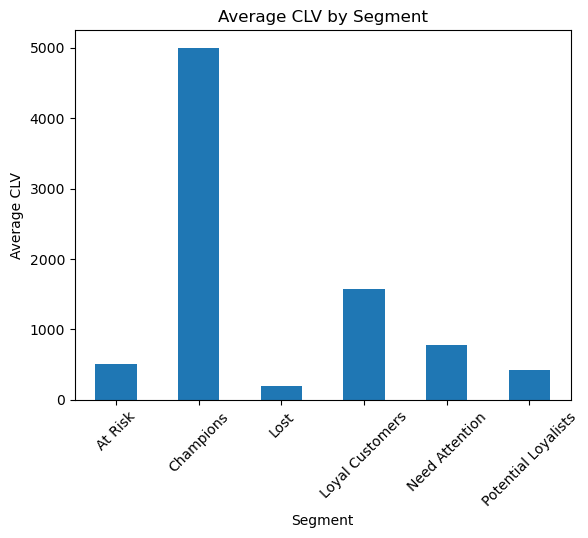

In [9]:
rfm.groupby('Segment')['CLV'].mean().plot(kind='bar')
plt.title('Average CLV by Segment')
plt.ylabel('Average CLV')
plt.xticks(rotation=45)
plt.show()

In [10]:
rfm.groupby('Segment')[['Monetary','CLV']].mean()

,Monetary,CLV
Segment,,
At Risk,877.853132,501.726028
Champions,5130.175070,4998.276206
Lost,477.678062,190.524699
Loyal Customers,2035.321906,1566.526305
Need Attention,848.291637,780.173551
Potential Loyalists,446.169122,423.787324


In [11]:
rfm.to_csv("../data/rfm_with_clv.csv", index=False)